<a href="https://colab.research.google.com/github/Yvr2812/ML---KNN/blob/main/ML_KNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Clasificación de Mensajes de Call Center mediante K Vecinos Más Cercanos (KNN)

Integrantes:
- Yuly Vanessa Ramos Romero


Clasifica automaticamente mensajes de texto de usuarios de un call center

In [2]:
!pip install sentence-transformers -q

import csv
import random
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
RUTA_CSV = '/content/drive/MyDrive/Machine Learning/dataset_acueducto_callcenter_v2.csv'

textos = []
clases = []

with open(RUTA_CSV, encoding='utf-8') as archivo:
    lector = csv.reader(archivo)
    next(lector)
    for fila in lector:
        if len(fila) >= 2:
            texto = fila[0].strip()
            clase = fila[1].strip()
            if texto and clase:
                textos.append(texto)
                clases.append(clase)

clases_unicas = sorted(set(clases))
print(f'Total de mensajes  : {len(textos)}')
print(f'Total de clases    : {len(clases_unicas)}')
print(f'Clases             : {clases_unicas}')

conteo = {}
for c in clases:
    conteo[c] = conteo.get(c, 0) + 1

print()
print('Mensajes por clase:')
for clase, n in sorted(conteo.items()):
    print(f'  {clase}: {n}')

Total de mensajes  : 600
Total de clases    : 6
Clases             : ['agua_contaminada', 'alcantarillado', 'baja_presion', 'fuga_agua', 'reconexion_servicio', 'sin_servicio']

Mensajes por clase:
  agua_contaminada: 100
  alcantarillado: 100
  baja_presion: 100
  fuga_agua: 100
  reconexion_servicio: 100
  sin_servicio: 100


In [4]:
print('Cargando modelo...')
modelo = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')
print('Modelo cargado.')

print('Generando embeddings...')
embeddings = modelo.encode(textos, show_progress_bar=True)
embeddings = [list(e) for e in embeddings]
print('Listo.')

print(f'\nCantidad de vectores  : {len(embeddings)}')
print(f'Dimensiones por vector: {len(embeddings[0])}')

Cargando modelo...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Modelo cargado.
Generando embeddings...


Batches:   0%|          | 0/19 [00:00<?, ?it/s]

Listo.

Cantidad de vectores  : 600
Dimensiones por vector: 384


In [6]:
#  División train/test

random.seed(42)

# Crear índices y mezclarlos
indices = list(range(len(textos)))
random.shuffle(indices)

corte = int(0.8 * len(indices))          # 80 % entrenamiento, 20 % prueba
idx_train = indices[:corte]
idx_test  = indices[corte:]

emb_train    = [embeddings[i] for i in idx_train]
clases_train = [clases[i]     for i in idx_train]
textos_train = [textos[i]     for i in idx_train]

emb_test     = [embeddings[i] for i in idx_test]
clases_test  = [clases[i]     for i in idx_test]
textos_test  = [textos[i]     for i in idx_test]

print(f'Entrenamiento : {len(emb_train)} muestras')
print(f'Prueba        : {len(emb_test)}  muestras')


Entrenamiento : 480 muestras
Prueba        : 120  muestras


In [7]:
# Funciones de distancia

def distancia_l1(a, b):
    #Suma de diferencias absolutas.
    return sum(abs(x - y) for x, y in zip(a, b))

def distancia_l2(a, b):
    #Raíz de la suma de diferencias al cuadrado (Euclídea).
    return sum((x - y) ** 2 for x, y in zip(a, b)) ** 0.5

def distancia_minkowski(a, b, p=3):
    #Generalización: p=1 → L1, p=2 → L2. Usamos p=3.
    return sum(abs(x - y) ** p for x, y in zip(a, b)) ** (1 / p)

def similitud_coseno(a, b):
    #Valor entre 0 y 1; más alto = más parecidos.
    dot   = sum(x * y for x, y in zip(a, b))
    norm_a = sum(x ** 2 for x in a) ** 0.5
    norm_b = sum(x ** 2 for x in b) ** 0.5
    if norm_a == 0 or norm_b == 0:
        return 0.0
    return dot / (norm_a * norm_b)

Funciones de distancia listas.


In [8]:
# Algoritmo KNN

def knn(embedding_consulta, emb_train, clases_train, k, metrica):

    # Clasifica embedding_consulta usando K vecinos más cercanos.

    # metrica: 'coseno' | 'l1' | 'l2' | 'minkowski'

    # Devuelve: (clase_predicha, lista de los k vecinos con su info)


    distancias = []

    for i, emb in enumerate(emb_train):
        if metrica == 'coseno':
            # Para coseno usamos 1 - similitud como "distancia"
            d = 1 - similitud_coseno(embedding_consulta, emb)
        elif metrica == 'l1':
            d = distancia_l1(embedding_consulta, emb)
        elif metrica == 'l2':
            d = distancia_l2(embedding_consulta, emb)
        elif metrica == 'minkowski':
            d = distancia_minkowski(embedding_consulta, emb, p=3)
        else:
            raise ValueError(f'Métrica desconocida: {metrica}')

        distancias.append((d, clases_train[i], i))

    # Ordenar de menor a mayor distancia y tomar los K primeros
    distancias.sort(key=lambda x: x[0])
    vecinos = distancias[:k]

    # Votación por mayoría
    votos = {}
    for d, clase, _ in vecinos:
        votos[clase] = votos.get(clase, 0) + 1

    clase_predicha = max(votos, key=votos.get)
    return clase_predicha, vecinos

Función KNN lista.


[1/24] metrica=coseno, K=1... exactitud = 0.692 ✓
[2/24] metrica=coseno, K=3... exactitud = 0.717 ✓
[3/24] metrica=coseno, K=5... exactitud = 0.717 ✓
[4/24] metrica=coseno, K=7... exactitud = 0.700 ✓
[5/24] metrica=coseno, K=9... exactitud = 0.700 ✓
[6/24] metrica=coseno, K=11... exactitud = 0.750 ✓
[7/24] metrica=l1, K=1... exactitud = 0.642 ✓
[8/24] metrica=l1, K=3... exactitud = 0.683 ✓
[9/24] metrica=l1, K=5... exactitud = 0.667 ✓
[10/24] metrica=l1, K=7... exactitud = 0.708 ✓
[11/24] metrica=l1, K=9... exactitud = 0.658 ✓
[12/24] metrica=l1, K=11... exactitud = 0.667 ✓
[13/24] metrica=l2, K=1... exactitud = 0.675 ✓
[14/24] metrica=l2, K=3... exactitud = 0.708 ✓
[15/24] metrica=l2, K=5... exactitud = 0.658 ✓
[16/24] metrica=l2, K=7... exactitud = 0.658 ✓
[17/24] metrica=l2, K=9... exactitud = 0.683 ✓
[18/24] metrica=l2, K=11... exactitud = 0.642 ✓
[19/24] metrica=minkowski, K=1... exactitud = 0.667 ✓
[20/24] metrica=minkowski, K=3... exactitud = 0.692 ✓
[21/24] metrica=minkowski, K

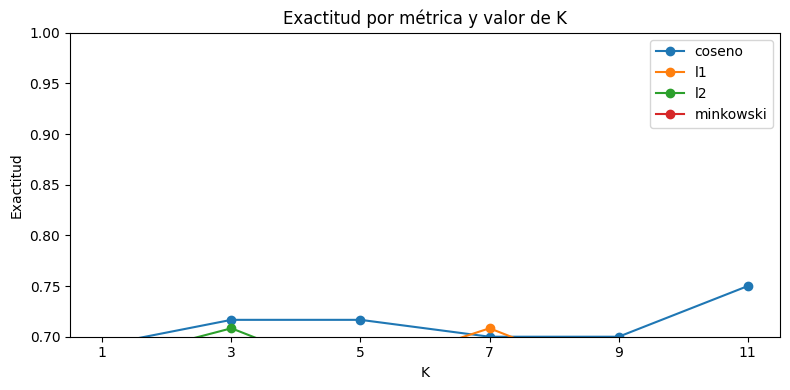

In [9]:
# Evaluación: métricas × valores de K

metricas  = ['coseno', 'l1', 'l2', 'minkowski']
valores_k = [1, 3, 5, 7, 9, 11]
resultados = {}

total_combos = len(metricas) * len(valores_k)
combo_actual = 0

for metrica in metricas:
    resultados[metrica] = {}
    for k in valores_k:
        combo_actual += 1
        print(f'[{combo_actual}/{total_combos}] metrica={metrica}, K={k}...', end=' ')

        aciertos = 0
        for emb_q, clase_real in zip(emb_test, clases_test):
            pred, _ = knn(emb_q, emb_train, clases_train, k, metrica)
            if pred == clase_real:
                aciertos += 1

        acc = aciertos / len(clases_test)
        resultados[metrica][k] = acc
        print(f'exactitud = {acc:.3f} ✓')

# ---- Tabla ----
print()
encabezado = f"{'Métrica':<12}" + "".join(f"  K={k}" for k in valores_k)
print(encabezado)
print('-' * len(encabezado))
for metrica in metricas:
    fila = f"{metrica:<12}"
    for k in valores_k:
        fila += f"  {resultados[metrica][k]:.3f}"
    print(fila)

# ---- Gráfica ----
plt.figure(figsize=(8, 4))
for metrica in metricas:
    accs = [resultados[metrica][k] for k in valores_k]
    plt.plot(valores_k, accs, marker='o', label=metrica)
plt.title('Exactitud por métrica y valor de K')
plt.xlabel('K')
plt.ylabel('Exactitud')
plt.xticks(valores_k)
plt.ylim(0.7, 1.0)
plt.legend()
plt.tight_layout()
plt.show()

Mejor métrica : coseno
Mejor K       : 11
Exactitud     : 0.750  (75.0 %)

Matriz de confusión  (métrica=coseno, K=11)

                        agua_conta  alcantaril  baja_presi   fuga_agua  reconexion  sin_servic
----------------------------------------------------------------------------------------------
agua_contaminada                15           2           0           0           0           1
alcantarillado                   2          16           0           2           0           2
baja_presion                     3           1          10           2           0           1
fuga_agua                        3           2           1          17           0           1
reconexion_servicio              2           0           0           1          14           2
sin_servicio                     1           0           0           1           0          18

Exactitud por clase:
  agua_contaminada       0.83  ████████████████
  alcantarillado         0.73  ██████████████
  ba

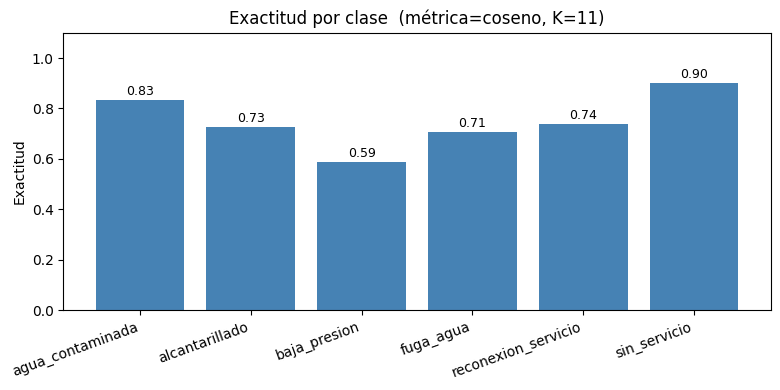

In [10]:
# Mejor configuración y análisis de confusiones

# Mejor K y métrica
mejor_acc     = 0
mejor_metrica = ''
mejor_k       = 0

for metrica in metricas:
    for k in valores_k:
        acc = resultados[metrica][k]
        if acc > mejor_acc:
            mejor_acc     = acc
            mejor_metrica = metrica
            mejor_k       = k

print(f'Mejor métrica : {mejor_metrica}')
print(f'Mejor K       : {mejor_k}')
print(f'Exactitud     : {mejor_acc:.3f}  ({mejor_acc*100:.1f} %)')

# Predicciones sobre test
predicciones = []
for emb_q in emb_test:
    pred, _ = knn(emb_q, emb_train, clases_train, mejor_k, mejor_metrica)
    predicciones.append(pred)

# Matriz de confusión
clases_unicas = sorted(set(clases))
matriz = {r: {c: 0 for c in clases_unicas} for r in clases_unicas}
for real, pred in zip(clases_test, predicciones):
    matriz[real][pred] += 1

print(f'\nMatriz de confusión  (métrica={mejor_metrica}, K={mejor_k})\n')
encabezado = f"{'':22}" + "".join(f"{c[:10]:>12}" for c in clases_unicas)
print(encabezado)
print('-' * len(encabezado))
for real in clases_unicas:
    fila = f"{real:<22}"
    for pred_c in clases_unicas:
        fila += f"{matriz[real][pred_c]:>12}"
    print(fila)

# Exactitud por clase
print('\nExactitud por clase:')
accs_por_clase = []
for clase in clases_unicas:
    total     = sum(matriz[clase].values())
    correctos = matriz[clase][clase]
    acc_clase = correctos / total if total > 0 else 0
    accs_por_clase.append(acc_clase)
    barra = '█' * int(acc_clase * 20)
    print(f'  {clase:<22} {acc_clase:.2f}  {barra}')

# Casos donde se confunde — CORREGIDO
print('\nEjemplos donde el modelo se confunde:')
mostrados = 0
for i, (real, pred) in enumerate(zip(clases_test, predicciones)):
    if real != pred and mostrados < 4:
        print(f'  Texto    : "{textos_test[i]}"')   # ← corregido
        print(f'  Real     : {real}')
        print(f'  Predicho : {pred}')
        print()
        mostrados += 1
if mostrados == 0:
    print('  El modelo acertó en todos los casos.')

# Gráfica por clase
plt.figure(figsize=(8, 4))
plt.bar(clases_unicas, accs_por_clase, color='steelblue')
plt.title(f'Exactitud por clase  (métrica={mejor_metrica}, K={mejor_k})')
plt.ylabel('Exactitud')
plt.ylim(0, 1.1)
plt.xticks(rotation=20, ha='right')
for i, v in enumerate(accs_por_clase):
    plt.text(i, v + 0.02, f'{v:.2f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

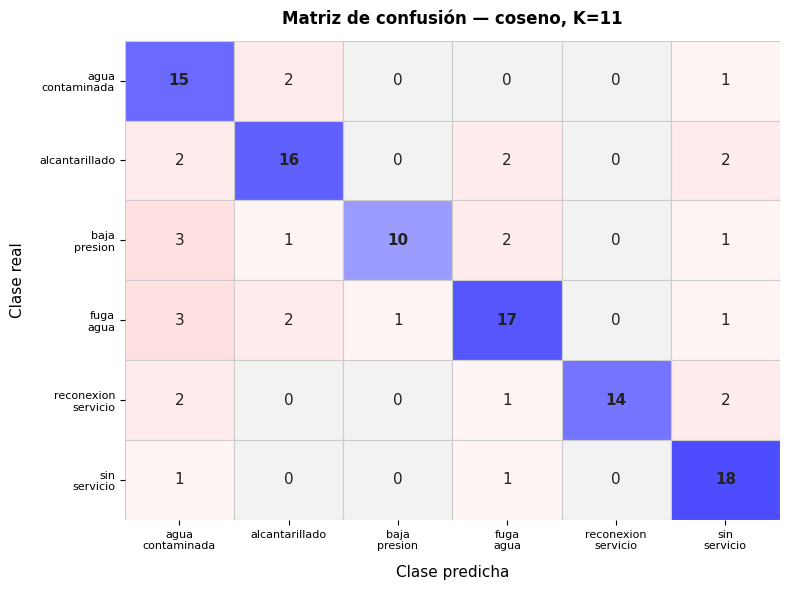

In [11]:
# Matriz de confusión visual


n = len(clases_unicas)
valores = [[matriz[r][p] for p in clases_unicas] for r in clases_unicas]
maximo  = max(v for fila in valores for v in fila)

fig, ax = plt.subplots(figsize=(8, 6))

for i in range(n):
    for j in range(n):
        val        = valores[i][j]
        intensidad = val / maximo if maximo > 0 else 0

        # Diagonal en azul, errores en rojo
        if i == j:
            color = (1 - intensidad * 0.7, 1 - intensidad * 0.7, 1.0)
        else:
            color = (1.0, 1 - intensidad * 0.7, 1 - intensidad * 0.7) if val > 0 else (0.95, 0.95, 0.95)

        ax.add_patch(plt.Rectangle((j, n - i - 1), 1, 1,
                                   color=color, ec='#CCCCCC', lw=0.8))
        ax.text(j + 0.5, n - i - 0.5, str(val),
                ha='center', va='center', fontsize=11,
                color='#222',
                fontweight='bold' if i == j else 'normal')

# Etiquetas
etiquetas = [c.replace('_', '\n') for c in clases_unicas]
ax.set_xticks([i + 0.5 for i in range(n)])
ax.set_xticklabels(etiquetas, fontsize=8)
ax.set_yticks([i + 0.5 for i in range(n)])
ax.set_yticklabels(reversed(etiquetas), fontsize=8)
ax.set_xlim(0, n)
ax.set_ylim(0, n)

ax.set_xlabel('Clase predicha', fontsize=11, labelpad=10)
ax.set_ylabel('Clase real',     fontsize=11, labelpad=10)
ax.set_title(f'Matriz de confusión — {mejor_metrica}, K={mejor_k}',
             fontsize=12, fontweight='bold', pad=12)
ax.spines[['top','right','left','bottom']].set_visible(False)

plt.tight_layout()
plt.show()

Clase                   Precisión     Recall         F1
-------------------------------------------------------
agua_contaminada            0.577      0.833      0.682
alcantarillado              0.762      0.727      0.744
baja_presion                0.909      0.588      0.714
fuga_agua                   0.739      0.708      0.723
reconexion_servicio         1.000      0.737      0.848
sin_servicio                0.720      0.900      0.800
-------------------------------------------------------
Promedio                    0.785      0.749      0.752


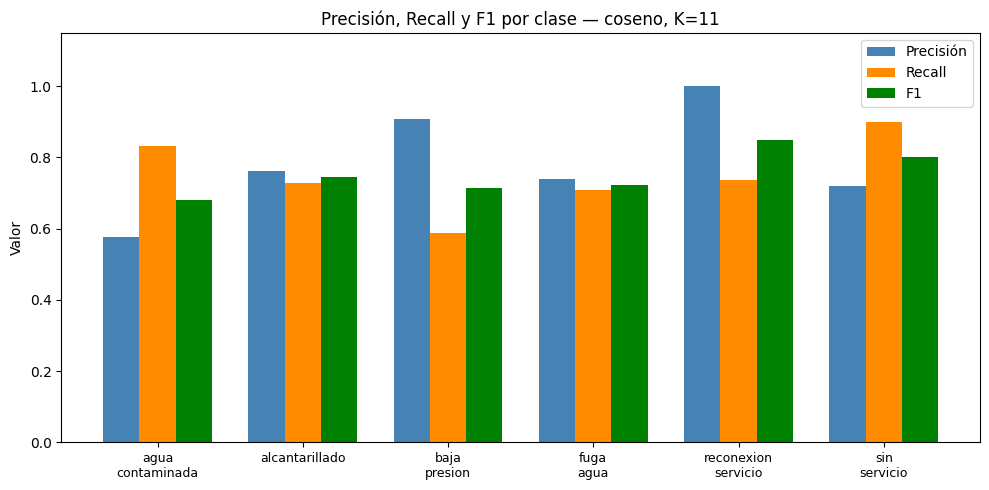

In [17]:
# Precisión, Recall y F1 por clase


def calcular_metricas(matriz, clases):
    resultados_metricas = {}
    for clase in clases:
        # Verdaderos positivos: predicho correcto
        vp = matriz[clase][clase]

        # Falsos positivos: otras clases predichas como esta
        fp = sum(matriz[otra][clase] for otra in clases if otra != clase)

        # Falsos negativos: esta clase predicha como otra
        fn = sum(matriz[clase][otra] for otra in clases if otra != clase)

        precision = vp / (vp + fp) if (vp + fp) > 0 else 0
        recall    = vp / (vp + fn) if (vp + fn) > 0 else 0
        f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

        resultados_metricas[clase] = {
            'precision': precision,
            'recall':    recall,
            'f1':        f1
        }
    return resultados_metricas

metricas_clase = calcular_metricas(matriz, clases_unicas)

# Tabla en consola
print(f'{"Clase":<22} {"Precisión":>10} {"Recall":>10} {"F1":>10}')
print('-' * 55)
for clase in clases_unicas:
    p  = metricas_clase[clase]['precision']
    r  = metricas_clase[clase]['recall']
    f1 = metricas_clase[clase]['f1']
    print(f'{clase:<22} {p:>10.3f} {r:>10.3f} {f1:>10.3f}')

# Promedio general
prom_p  = sum(metricas_clase[c]['precision'] for c in clases_unicas) / len(clases_unicas)
prom_r  = sum(metricas_clase[c]['recall']    for c in clases_unicas) / len(clases_unicas)
prom_f1 = sum(metricas_clase[c]['f1']        for c in clases_unicas) / len(clases_unicas)
print('-' * 55)
print(f'{"Promedio":<22} {prom_p:>10.3f} {prom_r:>10.3f} {prom_f1:>10.3f}')

# Gráfica
x = list(range(len(clases_unicas)))
ancho = 0.25

plt.figure(figsize=(10, 5))
plt.bar([i - ancho for i in x],
        [metricas_clase[c]['precision'] for c in clases_unicas],
        width=ancho, label='Precisión', color='steelblue')
plt.bar(x,
        [metricas_clase[c]['recall'] for c in clases_unicas],
        width=ancho, label='Recall', color='darkorange')
plt.bar([i + ancho for i in x],
        [metricas_clase[c]['f1'] for c in clases_unicas],
        width=ancho, label='F1', color='green')

plt.title(f'Precisión, Recall y F1 por clase — {mejor_metrica}, K={mejor_k}')
plt.ylabel('Valor')
plt.ylim(0, 1.15)
plt.xticks(x, [c.replace('_', '\n') for c in clases_unicas], fontsize=9)
plt.legend()
plt.tight_layout()
plt.show()

In [14]:
# Pruebas con mensajes fijos

mensajes_prueba = [
    ("el agua que llega a mi casa tiene un olor muy raro",     "agua_contaminada"),
    ("no tenemos agua desde ayer en todo el barrio",           "sin_servicio"),
    ("hay un tubo roto en la calle y sale mucha agua",         "fuga_agua"),
    ("la presion del agua es muy baja en las mañanas",         "baja_presion"),
    ("el alcantarillado esta desbordado frente a mi casa",     "alcantarillado"),
    ("necesito que me reconecten el servicio de agua",         "reconexion_servicio"),
    # Casos ambiguos
    ("el agua huele mal y ademas no llega con presion",        "agua_contaminada"),
    ("me cortaron el agua y quiero que me la vuelvan a poner", "reconexion_servicio"),
]

print(f'PRUEBAS CON K={mejor_k}')

for texto_prueba, clase_real in mensajes_prueba:
    emb_prueba = list(modelo.encode([texto_prueba])[0])
    print(f'\nMensaje : "{texto_prueba}"')
    print(f'Real    : {clase_real}')
    print(f'{"Métrica":<12}  {"Predicción":<22}  {"¿Acierta?"}')
    print('-' * 50)
    for metrica in metricas:
        pred, _ = knn(emb_prueba, emb_train, clases_train, mejor_k, metrica)
        acierto = 'OK' if pred == clase_real else 'X'
        print(f'{metrica:<12}  {pred:<22}  {acierto}')

PRUEBAS CON K=11

Mensaje : "el agua que llega a mi casa tiene un olor muy raro"
Real    : agua_contaminada
Métrica       Predicción              ¿Acierta?
--------------------------------------------------
coseno        agua_contaminada        OK
l1            agua_contaminada        OK
l2            agua_contaminada        OK
minkowski     agua_contaminada        OK

Mensaje : "no tenemos agua desde ayer en todo el barrio"
Real    : sin_servicio
Métrica       Predicción              ¿Acierta?
--------------------------------------------------
coseno        sin_servicio            OK
l1            sin_servicio            OK
l2            sin_servicio            OK
minkowski     sin_servicio            OK

Mensaje : "hay un tubo roto en la calle y sale mucha agua"
Real    : fuga_agua
Métrica       Predicción              ¿Acierta?
--------------------------------------------------
coseno        fuga_agua               OK
l1            fuga_agua               OK
l2            fuga_agua 

In [15]:
# Clasificador interactivo


def clasificar(mensaje, k=mejor_k, metrica=mejor_metrica):
    emb = list(modelo.encode([mensaje])[0])
    clase_pred, vecinos = knn(emb, emb_train, clases_train, k, metrica)

    print('=' * 60)
    print(f'  Mensaje         : {mensaje}')
    print(f'  Métrica         : {metrica}   |   K = {k}')
    print(f'  Clase predicha  : {clase_pred}')
    print()
    print(f'  {"#":<4} {"Clase vecino":<24} {"Distancia":>10}')
    print(f'  {"-"*4} {"-"*24} {"-"*10}')
    for i, (dist, clase_v, idx_v) in enumerate(vecinos, 1):
        print(f'  {i:<4} {clase_v:<24} {dist:>10.4f}')
        print(f'       "{textos[idx_train[idx_v]][:50]}"')
    print('=' * 60)

print(f'Clasificador listo  (K={mejor_k}, métrica={mejor_metrica})')
print('Escribe "salir" para terminar.\n')

while True:
    mensaje = input('Ingresa un mensaje: ').strip()
    if mensaje.lower() == 'salir':
        break
    if not mensaje:
        continue
    clasificar(mensaje)

Clasificador listo  (K=11, métrica=coseno)
Escribe "salir" para terminar.

Ingresa un mensaje: hay goteo en mi cocina
  Mensaje         : hay goteo en mi cocina
  Métrica         : coseno   |   K = 11
  Clase predicha  : alcantarillado

  #    Clase vecino              Distancia
  ---- ------------------------ ----------
  1    alcantarillado               0.4056
       "se esta desbordando una alcantarilla en santarita"
  2    fuga_agua                    0.4532
       "en myano hay una tuberia rota porfa revisar"
  3    alcantarillado               0.4756
       "en san carlos hay mal olo por el alcantarillado ne"
  4    alcantarillado               0.4774
       "se esta desbordndo una alcantarilla en villa alba "
  5    alcantarillado               0.4869
       "se esta desbordando una alcantarilla en san carlos"
  6    sin_servicio                 0.4908
       "en mi casa en sancarlos no ha llegado agua"
  7    alcantarillado               0.4917
       "en san carlos hay mal ol